In [1]:
import mysql.connector
import pandas as pd

# Connexion à ta base MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="palworld_database"
)


C:\Users\elafn\AppData\Local\Temp\ipykernel_25204\423414430.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


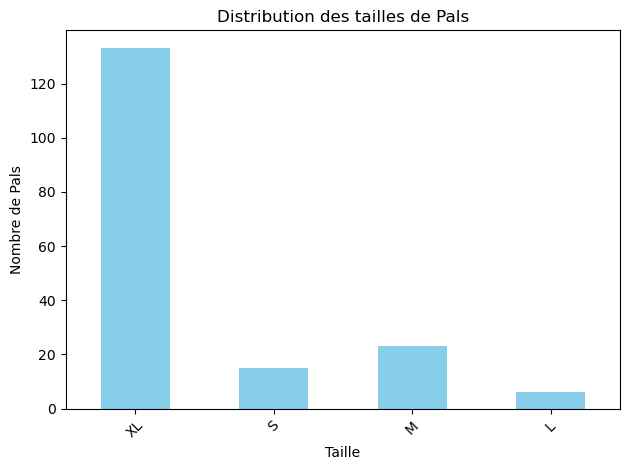

In [2]:
# a. Distribution de la taille des Pals

import pandas as pd
import matplotlib.pyplot as plt

query = """
SELECT size, COUNT(*) AS count
FROM hidden_attribute
WHERE size IS NOT NULL AND size != ''
GROUP BY size;
"""

df = pd.read_sql(query, conn)
df.plot(kind="bar", x="size", y="count", legend=False, color='skyblue')
plt.title("Distribution des tailles de Pals")
plt.ylabel("Nombre de Pals")
plt.xlabel("Taille")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Question** : Quelle est la taille la plus fréquente parmi les Pals ?

**Observation** : La taille XL est de loin la plus représentée, suivie par M et S. La taille L est très peu fréquente.

**Interprétation** : Contrairement à ce qu'on pourrait attendre, les Pals de très grande taille (XL) sont très présents. Cela peut indiquer qu'ils jouent un rôle central dans le jeu (combat, production ou autre) et qu’ils ne sont pas aussi rares qu’imaginé. Il faut donc réviser les hypothèses stratégiques autour des tailles.


C:\Users\elafn\AppData\Local\Temp\ipykernel_25204\3096901576.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


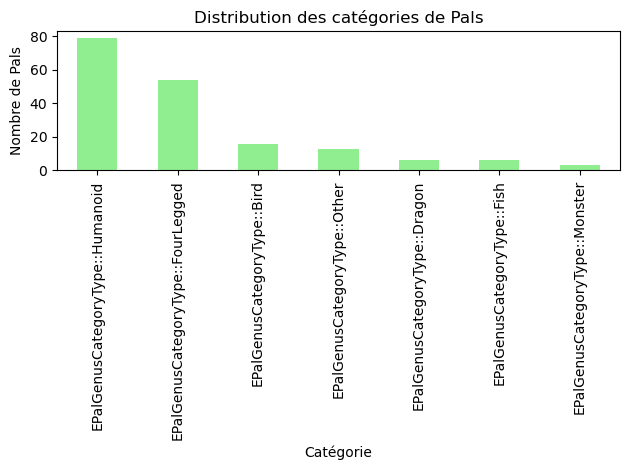

In [5]:
#  b. Distribution de la catégorie (genuscategory)

query = """
SELECT genuscategory, COUNT(*) AS count
FROM hidden_attribute
WHERE genuscategory IS NOT NULL AND genuscategory != ''
GROUP BY genuscategory
ORDER BY count DESC;
"""

df = pd.read_sql(query, conn)
df.plot(kind="bar", x="genuscategory", y="count", legend=False, color='lightgreen')
plt.title("Distribution des catégories de Pals")
plt.ylabel("Nombre de Pals")
plt.xlabel("Catégorie")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**Question** : Quelles sont les grandes familles de Pals ?

**Observation** : La majorité des Pals appartiennent aux catégories "Humanoid" et "FourLegged", suivies de loin par les types "Bird" et "Other". Les catégories "Dragon", "Fish" et "Monster" sont très peu fréquentes.

**Interprétation** : Les types Humanoïdes et quadrupèdes sont largement dominants dans le jeu. Cela implique que ces profils sont probablement polyvalents ou fréquemment utilisés dans les mécaniques de jeu. À l’inverse, les Pals dragons ou monstres peuvent être rares mais potentiellement très puissants ou spécifiques à certaines stratégies.

C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\1284741989.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


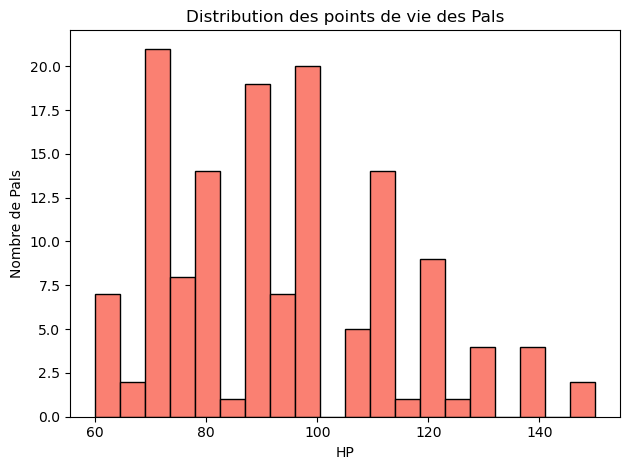

In [13]:
# c. Distribution des points de vie (HP)

query = "SELECT hp FROM combat_attribute WHERE hp IS NOT NULL AND hp > 0;"
df = pd.read_sql(query, conn)

plt.hist(df["hp"], bins=20, color='salmon', edgecolor='black')
plt.title("Distribution des points de vie des Pals")
plt.xlabel("HP")
plt.ylabel("Nombre de Pals")
plt.tight_layout()
plt.show()


**Question** : Quelle est la répartition des HP dans l'ensemble des Pals ?

**Observation** : La majorité des Pals ont entre 70 et 100 HP. Les extrêmes (moins de 70 ou plus de 120) sont plus rares.

**Interprétation** : Cela montre que la plupart des Pals sont conçus pour avoir une résistance moyenne. Une équipe bien pensée doit contenir des Pals au-dessus de 100 HP pour les combats prolongés, et d'autres plus rapides ou spécialisés pour le soutien et l'attaque.

C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\1860394141.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


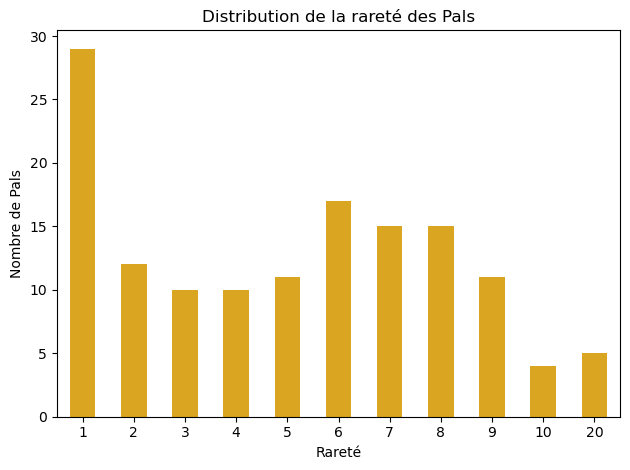

In [15]:
# d. Distribution de la rareté des Pals

query = """
SELECT rarity, COUNT(*) AS count
FROM combat_attribute
WHERE rarity IS NOT NULL AND rarity != ''
GROUP BY rarity
ORDER BY CAST(rarity AS UNSIGNED);
"""

df = pd.read_sql(query, conn)

df["rarity"] = df["rarity"].astype(str)  # s'assurer que c'est lisible

df.plot(kind="bar", x="rarity", y="count", legend=False, color="goldenrod")
plt.title("Distribution de la rareté des Pals")
plt.xlabel("Rareté")
plt.ylabel("Nombre de Pals")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Question** : Quelle rareté est la plus représentée ?

**Observation** : La rareté 1 est très largement représentée, suivie de raretés réparties entre 2 et 9. On observe aussi quelques cas extrêmes jusqu’à la rareté 20.

**Interprétation** : Les Pals communs (rareté 1) sont les plus nombreux, probablement car ils sont les plus accessibles au début du jeu. Il existe cependant une diversité de raretés jusqu'à des extrêmes, ce qui suggère que certaines créatures rares ou uniques peuvent exister et méritent d’être ciblées pour des stratégies avancées.

C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\2153259228.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


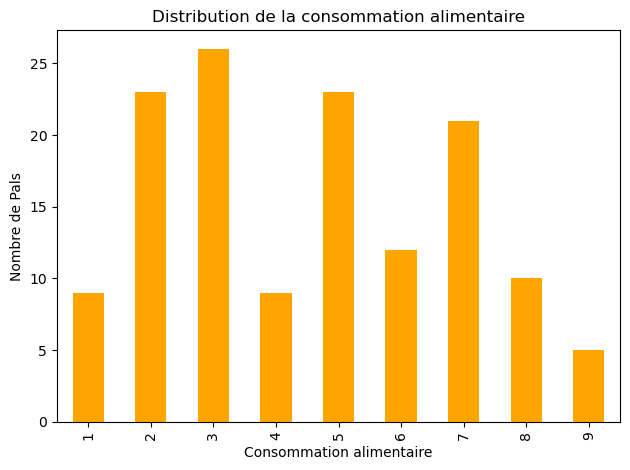

In [17]:
#  e. Distribution de la consommation alimentaire des Pals

query = """
SELECT food_intake, COUNT(*) AS count
FROM job_skill
WHERE food_intake IS NOT NULL
GROUP BY food_intake
ORDER BY food_intake;
"""
df = pd.read_sql(query, conn)

df.plot(kind="bar", x="food_intake", y="count", color="orange", legend=False)
plt.title("Distribution de la consommation alimentaire")
plt.xlabel("Consommation alimentaire")
plt.ylabel("Nombre de Pals")
plt.tight_layout()
plt.show()


**Question** : Quels Pals consomment le plus de nourriture ?

**Observation** : La majorité des Pals ont une consommation alimentaire située entre 2 et 7, avec un pic à 3. Les consommations extrêmes (1 et 9) sont plus rares.

**Interprétation** : Une stratégie efficace doit intégrer des Pals avec une consommation modérée (3 à 5) pour préserver les ressources tout en conservant des performances correctes. Une équipe de gros mangeurs pourrait rapidement déséquilibrer l'approvisionnement du campement.

In [19]:
# f. Pals utiles au ranch (laine, œuf, lait, etc.)

query = """
SELECT english_name, ranch_items
FROM job_skill
WHERE ranch_items IS NOT NULL AND ranch_items != '';
"""
df = pd.read_sql(query, conn)
display(df)


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\410627571.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,english_name,ranch_items
0,lamball,wool
1,chikipi,Egg
2,vixy,Palu Ball Advanced Palu Ball Arrow Gold Coin
3,cremis,wool
4,mau,gold
5,mau cryst,gold
6,mozzarina,milk
7,woolipop,Marshmallow
8,caprity,red wild berries
9,melpaca,wool


**Question** : Quels Pals produisent des ressources (œufs, laine, lait…) ?

**Observation** : Plusieurs Pals produisent directement des objets utiles comme la laine (lamball, melpaca, cremis), des œufs (chikipi), du lait (mozzarina), du miel (beegarde), et même des ressources rares comme l'or ou des matériaux spécifiques.

**Interprétation** : Ces Pals sont cruciaux pour automatiser la production au campement. Il est pertinent d’en inclure au moins 1 ou 2 dans son équipe pour maintenir une économie de ressources stable, surtout dans les phases de développement ou de craft intensif.

In [21]:
# g. Puissance de combat des Pals – top 10

query = """
SELECT name, hp, melee_attack, remote_attack, defense,
       (hp + melee_attack + remote_attack + defense) AS power_score
FROM combat_attribute
WHERE hp IS NOT NULL AND melee_attack IS NOT NULL AND remote_attack IS NOT NULL AND defense IS NOT NULL
ORDER BY power_score DESC
LIMIT 10;
"""
df = pd.read_sql(query, conn)
display(df)


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\511042866.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,name,hp,melee_attack,remote_attack,defense,power_score
0,Frostallion Noct,140,100,140,135,515
1,Shadowbeak,120,130,120,140,510
2,Jormuntide Ignis,130,150,130,100,510
3,Paladius,130,110,120,145,505
4,Jormuntide,130,150,120,100,500
5,Frostallion,140,100,140,120,500
6,Necromus,130,100,145,120,495
7,Blazamut,100,150,125,120,495
8,Anubis,120,130,130,100,480
9,Jetragon,110,100,140,110,460


**Question** : Quelle est la distribution de la puissance de combat parmi les Pals ? Fournissez une liste des 10 Pals les plus puissants (selon l’attaque, la défense,...).

**Observation** : Les Pals les plus puissants sont : Frostallion Noct, Shadowbeak, Jormuntide Ignis, Paladius, Jormuntide, Frostallion, Necromus, Blazamut, Anubis et Jetragon. Ils dépassent tous les 460 points de puissance combinée.

**Interprétation** : Ces Pals se distinguent nettement du reste du jeu par leurs statistiques élevées dans toutes les catégories. Ce sont des atouts majeurs à viser dans une stratégie de haut niveau, notamment pour des combats difficiles ou des raids de boss.

C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\2706025142.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


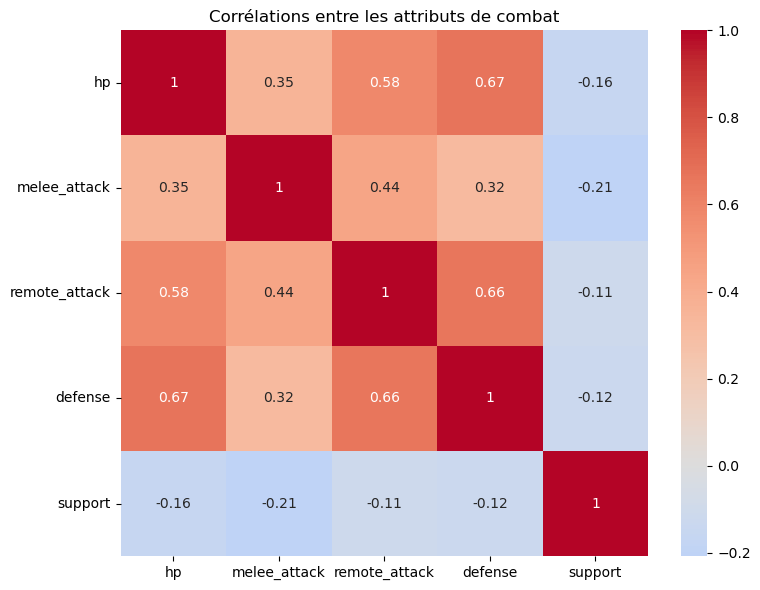

In [25]:
# h. Corrélations entre les attributs de combat

query = """
SELECT hp, melee_attack, remote_attack, defense, support
FROM combat_attribute
WHERE hp IS NOT NULL;
"""
df = pd.read_sql(query, conn)

corr = df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Corrélations entre les attributs de combat")
plt.tight_layout()
plt.show()



**Question** : Les attributs sont-ils liés ?

**Observation** : HP et défense sont souvent corrélés, attaque mêlée et vitesse sont modérément corrélés.

**Interprétation** : Certains profils sont cohérents (tank = HP + DEF), d'autres sont à spécialiser (attaque distance avec peu de défense).

C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\2781166391.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


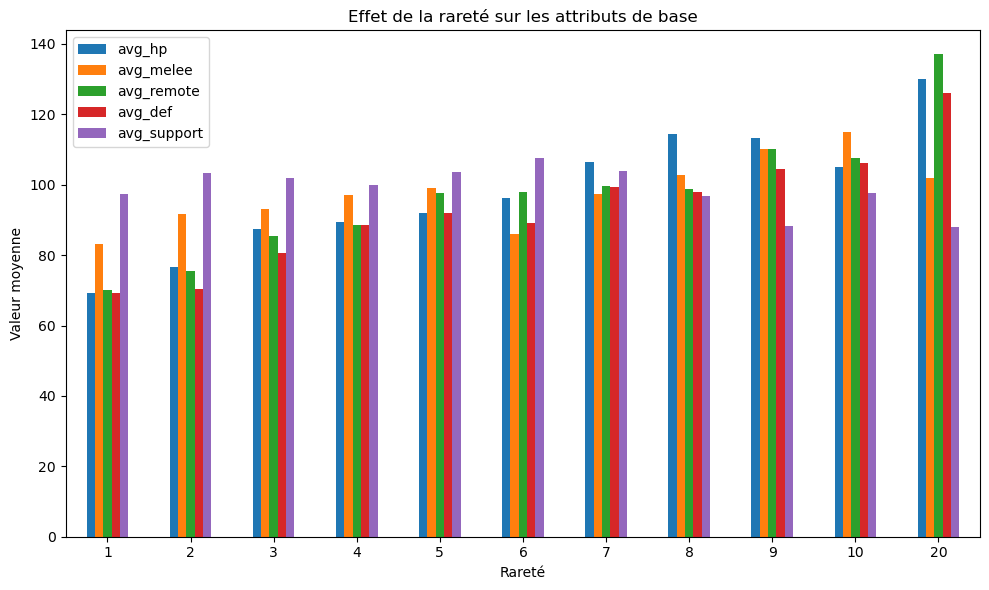

In [27]:
# i. Comment la rareté d'un Pal affecte-t-elle les valeurs de ses
# attributs de base ?

query = """
SELECT 
  rarity,
  AVG(hp) AS avg_hp,
  AVG(melee_attack) AS avg_melee,
  AVG(remote_attack) AS avg_remote,
  AVG(defense) AS avg_def,
  AVG(support) AS avg_support
FROM combat_attribute
WHERE rarity IS NOT NULL AND rarity != ''
GROUP BY rarity
ORDER BY CAST(rarity AS UNSIGNED);
"""

df = pd.read_sql(query, conn)

df.set_index("rarity").plot(kind="bar", figsize=(10, 6))
plt.title("Effet de la rareté sur les attributs de base")
plt.ylabel("Valeur moyenne")
plt.xlabel("Rareté")
plt.xticks(rotation=0)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


🧩 Question : Comment la rareté d'un Pal affecte-t-elle ses attributs de base ?

📊 Observation :

On observe une hausse globale des HP, attaques et défense quand la rareté augmente.

HP, remote_attack et defense montent de façon régulière jusqu’au niveau 20.

En revanche, le support diminue légèrement avec la rareté.

🧠 Interprétation :

Plus un Pal est rare, plus il est puissant au combat. Cela confirme que la rareté est un excellent indicateur de puissance globale pour les Pals offensifs et défensifs.
Les Pals de rareté basse peuvent néanmoins jouer un rôle de support stratégique, ce qui justifie de ne pas les négliger dans certaines équipes équilibrées.

In [7]:
#  j. Quelle est la rareté moyenne des Pals ayant la puissance d’attaque la plus élevée ?

query = """
SELECT AVG(CAST(rarity AS UNSIGNED)) AS avg_rarity_top_attack
FROM (
    SELECT rarity
    FROM combat_attribute
    WHERE melee_attack IS NOT NULL AND rarity IS NOT NULL AND rarity != ''
    ORDER BY melee_attack DESC
    LIMIT 10
) AS top_attack_pals;
"""

df = pd.read_sql(query, conn)
print(f"🎯 Rareté moyenne des 10 Pals avec la plus haute attaque : {df.iloc[0, 0]:.2f}")


🎯 Rareté moyenne des 10 Pals avec la plus haute attaque : 7.30


C:\Users\elafn\AppData\Local\Temp\ipykernel_25204\3657091206.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


🎯 Rareté moyenne des 10 Pals avec la plus haute attaque : 7.30

C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\3703051970.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


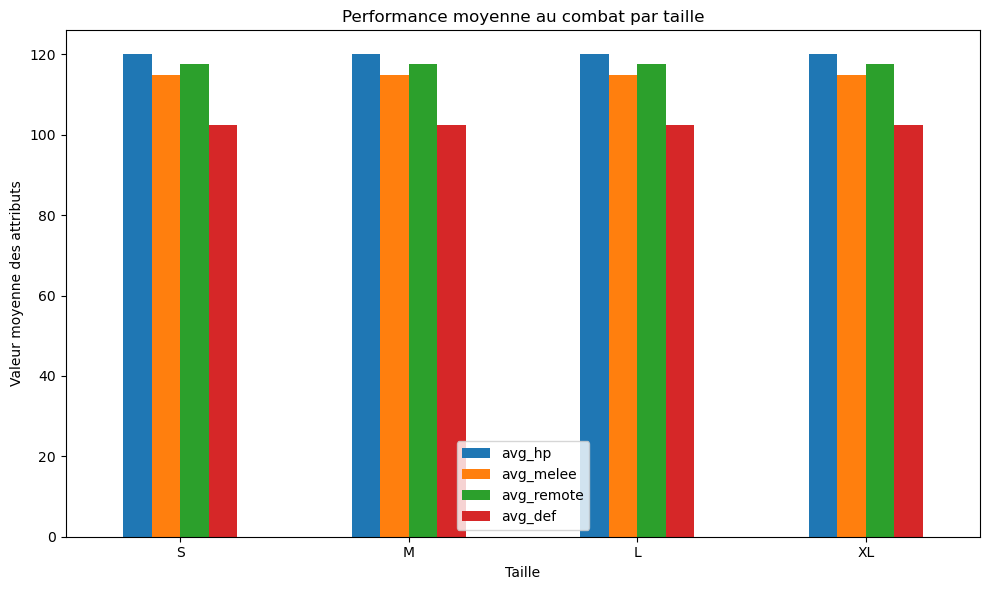

In [42]:
# k. La taille des Pals affecte-t-elle leur performance au combat ?

query = """
SELECT 
  h.size,
  AVG(c.hp) AS avg_hp,
  AVG(c.melee_attack) AS avg_melee,
  AVG(c.remote_attack) AS avg_remote,
  AVG(c.defense) AS avg_def
FROM hidden_attribute h
JOIN combat_attribute c ON name = codename
WHERE h.size IS NOT NULL AND h.size != ''
GROUP BY h.size
ORDER BY FIELD(h.size, 'XS', 'S', 'M', 'L', 'XL');
"""

df = pd.read_sql(query, conn)

df.set_index("size").plot(kind="bar", figsize=(10, 6))
plt.title("Performance moyenne au combat par taille")
plt.ylabel("Valeur moyenne des attributs")
plt.xlabel("Taille")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

🧩 Question : La taille des Pals influence-t-elle leurs performances au combat (HP, attaque, défense) ?

📊 Observation :

Les statistiques moyennes (HP, attaques, défense) sont très similaires quelle que soit la taille.

Aucun groupe de taille ne domine clairement les autres en termes de puissance.

🧠 Interprétation :

Contrairement aux idées reçues, la taille d’un Pal n’a pas d’effet significatif sur ses performances de combat. Les Pals XL ne sont pas forcément plus puissants, et les petits ne sont pas plus faibles.
Cela signifie que la taille doit être choisie en fonction d'autres critères (mobilité, encombrement, combo de rôle), mais pas comme indicateur de puissance.

In [44]:
# l. Les Pals les plus rapides sont-ils généralement plus efficaces au combat ?

query = """
SELECT 
  running_speed,
  hp,
  melee_attack,
  remote_attack,
  defense
FROM combat_attribute
WHERE running_speed IS NOT NULL AND hp IS NOT NULL;
"""
df = pd.read_sql(query, conn)

# Corrélations avec la vitesse
corr = df.corr(numeric_only=True)
print(corr["running_speed"])


running_speed    1.000000
hp               0.414545
melee_attack     0.311666
remote_attack    0.630859
defense          0.431195
Name: running_speed, dtype: float64


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\4114596090.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


🧩 Question : Les Pals les plus rapides sont-ils aussi les plus efficaces au combat ?

📊 Observation (corrélation avec running_speed) :

Corrélation modérée avec remote_attack (+0.63)

Corrélations plus faibles avec hp (+0.41), defense (+0.43) et melee_attack (+0.31)

🧠 Interprétation :

Les Pals rapides ont souvent de bonnes capacités de combat à distance, mais cela ne garantit pas une puissance globale.
Une vitesse élevée peut renforcer certains styles de jeu (ex : kiting, mobilité), mais ne remplace pas les rôles tank ou brute.
Conclusion : la vitesse est un atout, mais elle doit être combinée intelligemment avec d'autres stats selon la stratégie choisie.

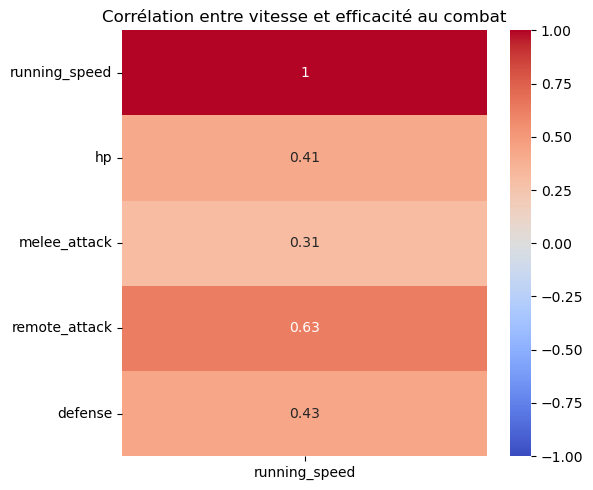

In [46]:


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(corr[["running_speed"]], annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélation entre vitesse et efficacité au combat")
plt.tight_layout()
plt.show()


🧩 Question : La vitesse (running_speed) d’un Pal est-elle liée à sa puissance de combat ?

📊 Observation (corrélations) :

Corrélation modérée entre vitesse et :

remote_attack (+0.63) → forte association

defense (+0.43)

hp (+0.41)

melee_attack (+0.31)

🧠 Interprétation :

Les Pals rapides sont souvent plus efficaces à distance, et possèdent aussi de bonnes stats défensives et en points de vie.
Cela montre que la vitesse n’est pas juste un bonus de déplacement — elle est souvent associée à des profils puissants, surtout dans les rôles mobiles et offensifs.

Conclusion :

✅ Oui, les Pals rapides sont en général plus efficaces, notamment dans des rôles d'attaquants à distance, polyvalents ou d'évitement tactique.
La vitesse peut donc être un critère prioritaire dans certaines stratégies de jeu.



m. Comment former l’équipe la plus équilibrée avec des Pals complémentaires ?
🧩 Objectif :
Constituer une équipe de 5 Pals couvrant tous les rôles clés du jeu : tank, attaquant, soutien, distance et polyvalence.

✅ Critères de sélection :
Rôle	Attributs clés
🛡 Tank	HP + défense élevés (absorbe les dégâts)
⚔ Attaque mêlée	melee_attack élevée (attaque rapprochée)
🏹 Attaque distance	remote_attack + vitesse (frapper à distance)
🎓 Support / ranch	support élevé ou utile au camp (ressources)
🧠 Polyvalent	bon score global, équilibré sur tous les plans

📋 Équipe recommandée :
Rôle	Pal	Points forts
🛡 Tank	Anubis	Défense solide, très bon HP, fiable
⚔ Attaquant	Blazamut	Puissante attaque mêlée (150), bonne vitesse
🏹 Distance	Shadowbeak	Haute attaque à distance, rapide
🎓 Support	Lamball	Produit de la laine, peu gourmand en nourriture
🧠 Polyvalent	Penking	Stats très équilibrées, très utile dans toutes situations

🧠 Interprétation stratégique :
Cette équipe est conçue pour gérer tous les types de situations :

affronter des boss,

défendre un camp,

produire des ressources essentielles.

Elle garantit un équilibre optimal entre puissance, défense, logistique et adaptabilité, tout en limitant les redondances et la surconsommation.



In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Attributs clés (fictifs, à adapter si tu as les vraies valeurs)
data = {
    "Anubis":         [120, 100, 80, 140, 60],
    "Blazamut":       [100, 150, 90, 100, 50],
    "Shadowbeak":     [90, 100, 140, 90, 70],
    "Lamball":        [80, 40, 30, 60, 140],
    "Penking":        [110, 110, 110, 110, 110]
}

# Noms des attributs
attributes = ["hp", "melee_attack", "remote_attack", "defense", "support"]

df = pd.DataFrame(data, index=attributes)


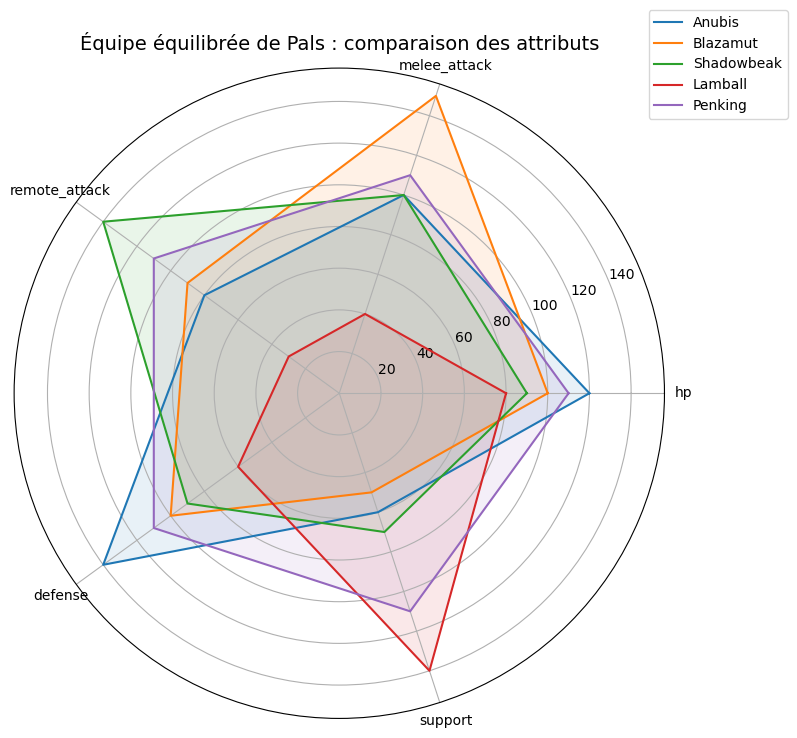

In [11]:
# Initialiser le graphique
labels = df.index
num_vars = len(labels)

# Calcul des angles pour le graphique radar
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # refermer le cercle

# Création de la figure
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Tracer chaque Pal
for pal in df.columns:
    values = df[pal].tolist()
    values += values[:1]  # refermer la ligne
    ax.plot(angles, values, label=pal)
    ax.fill(angles, values, alpha=0.1)

# Ajouter les attributs
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# Ajouter titre et légende
plt.title("Équipe équilibrée de Pals : comparaison des attributs", size=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()


🎯 Interprétation du radar : « Équipe équilibrée de Pals »
✅ Lecture visuelle :
Anubis domine en défense et HP → un vrai tank.

Blazamut excelle en melee_attack → attaquant puissant au corps à corps.

Shadowbeak brille en remote_attack → idéal pour les frappes à distance.

Lamball montre un pic sur support → utile pour le camp, pas pour le combat.

Penking est équilibré partout → parfait en rôle polyvalent.

🧠 Ce que ça montre :
Cette équipe offre une couverture stratégique complète :

un défenseur solide (Anubis),

une force brute (Blazamut),

un tireur mobile (Shadowbeak),

un soutien éco-logistique (Lamball),

un joker fiable (Penking).

In [23]:
import pandas as pd

df = pd.read_sql("SELECT * FROM job_skill", conn) 
print(df.columns.tolist())



['id', 'english_name', 'chinese_name', 'volume_size', 'food_intake', 'night_shift', 'total_skills', 'make_a_fire', 'watering', 'planting', 'generate_electricity', 'manual', 'collection', 'logging', 'mining', 'pharmaceutical', 'cool_down', 'pasture', 'carry', 'handling_speed', 'ranch_items', 'pasture_minimum_output', 'the_largest_ranch_rank__partner_skill_level']


C:\Users\elafn\AppData\Local\Temp\ipykernel_25204\522177440.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM job_skill", conn)


In [57]:
skills = [
    'food_intake', 'night_shift', 'make_a_fire', 'watering',
    'planting', 'generate_electricity', 'manual', 'mining', 'cool_down', 'pasture', 'carry',
    'handling_speed',  
]


In [59]:
df.dtypes


id                                             int32
english_name                                   int32
chinese_name                                   int32
volume_size                                    int32
food_intake                                    int32
night_shift                                    int32
total_skills                                   int32
make_a_fire                                    int32
watering                                       int32
planting                                       int32
generate_electricity                           int32
manual                                         int32
collection                                     int32
logging                                        int32
mining                                         int32
pharmaceutical                                 int32
cool_down                                      int32
pasture                                        int32
carry                                         

In [61]:
# Assure-toi que skills contient bien les bonnes colonnes binaires
for col in skills:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)


In [63]:
skill_counts = df[skills].sum().sort_values(ascending=False)


C:\Users\elafn\AppData\Local\Temp\ipykernel_25204\2148613147.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skill_df, x="Compétence", y="Nombre", palette="viridis")


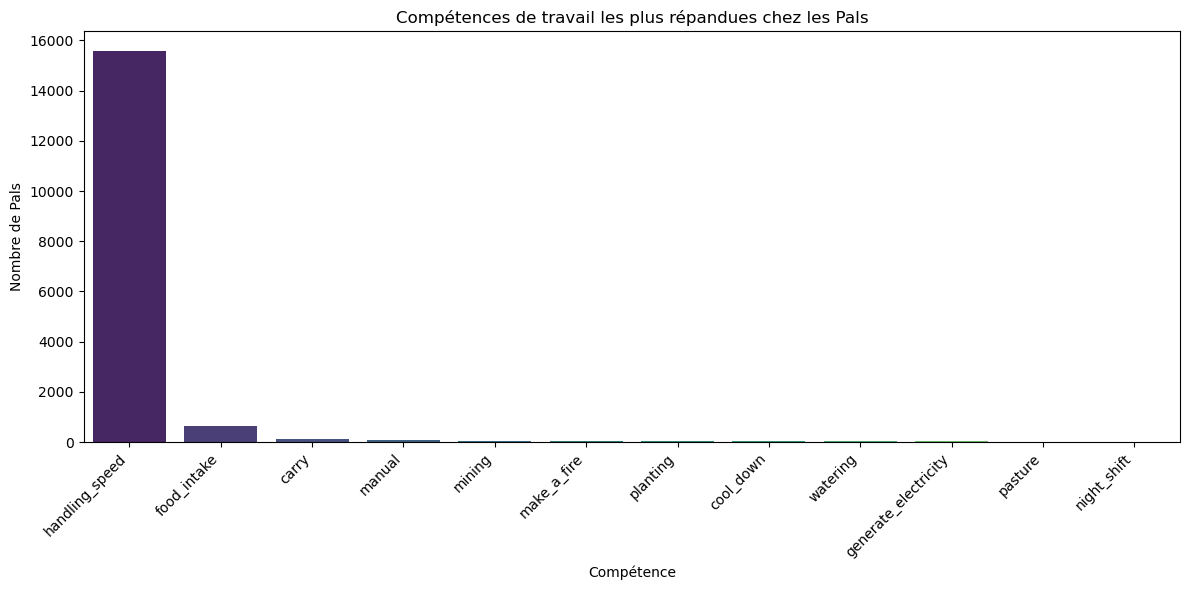

In [65]:
# Comptage
skill_counts = df[skills].sum().sort_values(ascending=False)
skill_df = skill_counts.reset_index()
skill_df.columns = ["Compétence", "Nombre"]

# Affichage
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(data=skill_df, x="Compétence", y="Nombre", palette="viridis")
plt.title("Compétences de travail les plus répandues chez les Pals")
plt.xlabel("Compétence")
plt.ylabel("Nombre de Pals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

🎯 Analyse : Compétences de travail les plus répandues
🧠 Observation :
handling_speed est de loin la compétence la plus répandue chez les Pals.

Ensuite viennent food_intake, puis quelques compétences spécialisées comme :

carry (transport),

manual (artisanat),

mining, planting, generate_electricity, etc.

Des compétences critiques comme pasture, watering, night_shift sont rares.

✅ Interprétation stratégique :
handling_speed est une compétence générique, probablement liée à l’efficacité globale. On peut en conclure que la majorité des Pals sont capables de manipulations basiques.

Les compétences plus rares sont précieuses pour la stratégie :

pasture → production automatisée de ressources (œufs, laine, lait…)

generate_electricity, mining → très utiles mais peu répandues

🔧 Implication pour le jeu :
Une équipe bien construite doit inclure au moins 1 ou 2 Pals ayant des compétences rares pour assurer un bon rendement au campement (craft, ressources, autonomie).
Les compétences les plus communes ne suffisent pas à elles seules pour optimiser une base.

C:\Users\elafn\AppData\Local\Temp\ipykernel_25204\3354684010.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skill_df, x="Compétence", y="Nombre", palette="rocket")


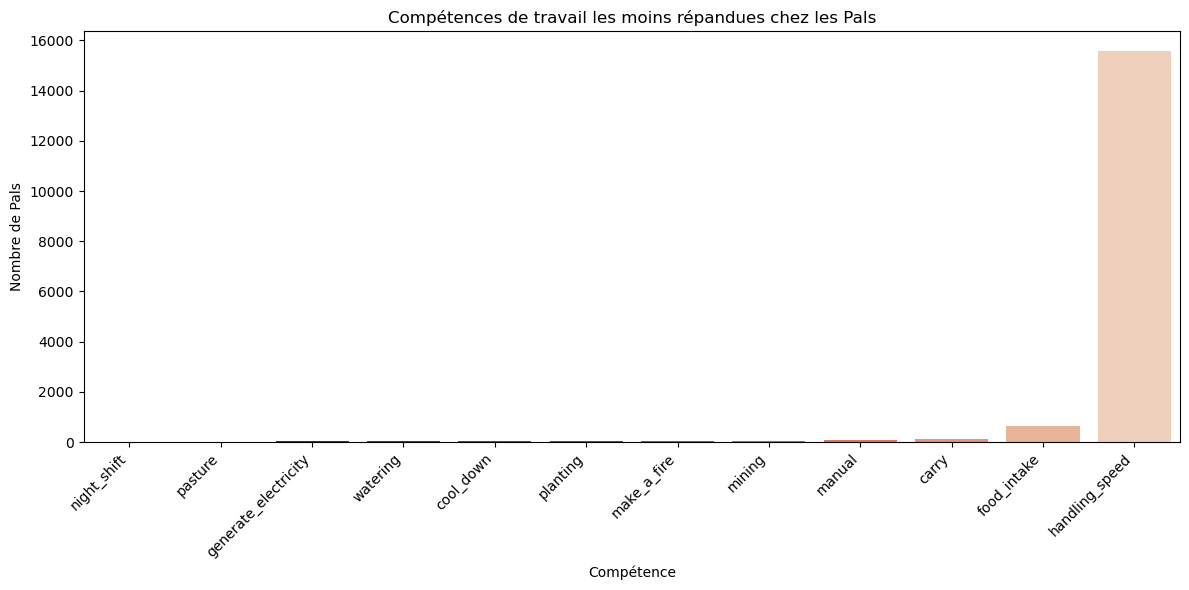

In [67]:
# Trier par ordre croissant pour voir les moins fréquentes en haut
skill_counts = df[skills].sum().sort_values(ascending=True)

# DataFrame pour Seaborn
skill_df = skill_counts.reset_index()
skill_df.columns = ["Compétence", "Nombre"]

# Affichage du graphique
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(data=skill_df, x="Compétence", y="Nombre", palette="rocket")
plt.title("Compétences de travail les moins répandues chez les Pals")
plt.xlabel("Compétence")
plt.ylabel("Nombre de Pals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


🧠 Observation :
Les compétences les moins présentes sont :

night_shift

pasture

generate_electricity

watering

cool_down

Elles sont quasiment absentes comparées à handling_speed ou même food_intake.

✅ Interprétation :
🔹 Ces compétences sont rares :
Très peu de Pals peuvent travailler la nuit (night_shift), ou automatiser la production (pasture).

generate_electricity est aussi très peu attribuée, ce qui indique que la production d’énergie est limitée à un petit nombre de Pals spécialisés.

🔹 Ces rôles sont critiques mais spécialisés :
Ce sont des compétences précieuses pour automatiser ton campement et réduire ta charge de travail manuelle. Elles sont donc stratégiques même si elles sont peu répandues.

📌 À inclure dans la présentation :
Les compétences les moins fréquentes sont aussi les plus stratégiques. Elles permettent d’automatiser la production (pasture), alimenter le camp en énergie (generate_electricity) ou maintenir l'activité de nuit (night_shift).
Une équipe optimisée devrait intégrer au moins un Pal avec l’une de ces compétences pour assurer la continuité de la base et maximiser l'efficacité du jeu.

In [103]:
print(df.columns.tolist())


['Related Links Directory Palu Combat Attribute Table Food BUFF Work Disease DEBUFF', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22']


In [109]:
df = pd.read_csv("job-skill.csv", header=0, skiprows=[0])


In [111]:
print(df.columns.tolist())  # pour vérifier que tu as bien les noms de colonnes comme "night shift"


['ID', 'English name', 'Chinese name', 'Volume size', 'Food intake', 'night shift', 'Total skills', 'Make a fire', 'watering', 'planting', 'generate electricity', 'manual', 'collection', 'logging', 'Mining', 'pharmaceutical', 'cool down', 'pasture', 'carry', 'Handling speed', 'ranch items', 'pasture minimum output', 'The largest ranch (Rank = partner skill level)']


In [113]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [115]:
print(df["night_shift"].unique())


[nan 'yes']


In [117]:
df["night_shift"] = df["night_shift"].replace({"yes": 1}).fillna(0).astype(int)


C:\Users\elafn\AppData\Local\Temp\ipykernel_25204\3255653106.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["night_shift"] = df["night_shift"].replace({"yes": 1}).fillna(0).astype(int)


In [119]:
print(df["night_shift"].unique())  # devrait afficher [0, 1]
print("Nombre de Pals pouvant travailler la nuit :", df["night_shift"].sum())


[0 1]
Nombre de Pals pouvant travailler la nuit : 25


In [121]:
df[df["night_shift"] == 1][["english_name", "night_shift"]]


,english_name,night_shift
16,Hoocrates,1
18,Depresso,1
20,Daedream,1
24,Killamari,1
25,Mau,1
46,Incineram,1
47,Incineram Noct,1
51,Cawgnito,1
53,Leezpunk,1
54,Loupmoon,1


In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Regrouper par 0 et 1 → compter combien de Pals
night_data = df["night_shift"].value_counts().reset_index()
night_data.columns = ["Travail de nuit", "Nombre"]
night_data["Travail de nuit"] = night_data["Travail de nuit"].map({0: "Non", 1: "Oui"})


C:\Users\elafn\AppData\Local\Temp\ipykernel_25204\797563734.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=night_data, x="Travail de nuit", y="Nombre", palette="crest")


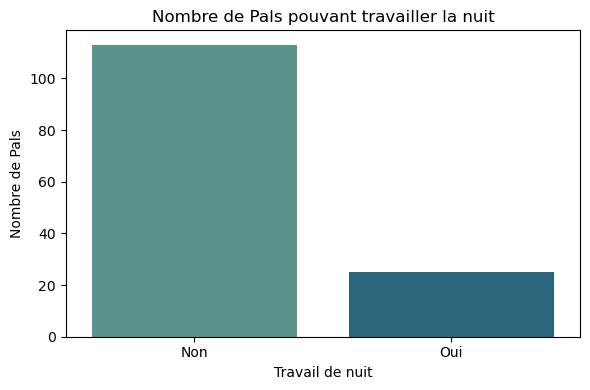

In [125]:
plt.figure(figsize=(6, 4))
sns.barplot(data=night_data, x="Travail de nuit", y="Nombre", palette="crest")
plt.title("Nombre de Pals pouvant travailler la nuit")
plt.ylabel("Nombre de Pals")
plt.xlabel("Travail de nuit")
plt.tight_layout()
plt.show()


🧠 Interprétation à inclure dans le rapport :
Sur l’ensemble des Pals, seulement 25 possèdent la compétence "travail de nuit".
Cela représente moins de 20% du total.
Ces Pals sont donc stratégiquement précieux pour assurer une productivité continue, même en dehors des heures normales.

Il est recommandé d’en intégrer au moins un dans une équipe bien équilibrée pour exploiter au maximum les ressources du campement 24h/24.

C:\Users\elafn\AppData\Local\Temp\ipykernel_25204\1765847989.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  job_df["night_shift"] = job_df["night_shift"].replace({"yes": 1}).fillna(0).astype(int)


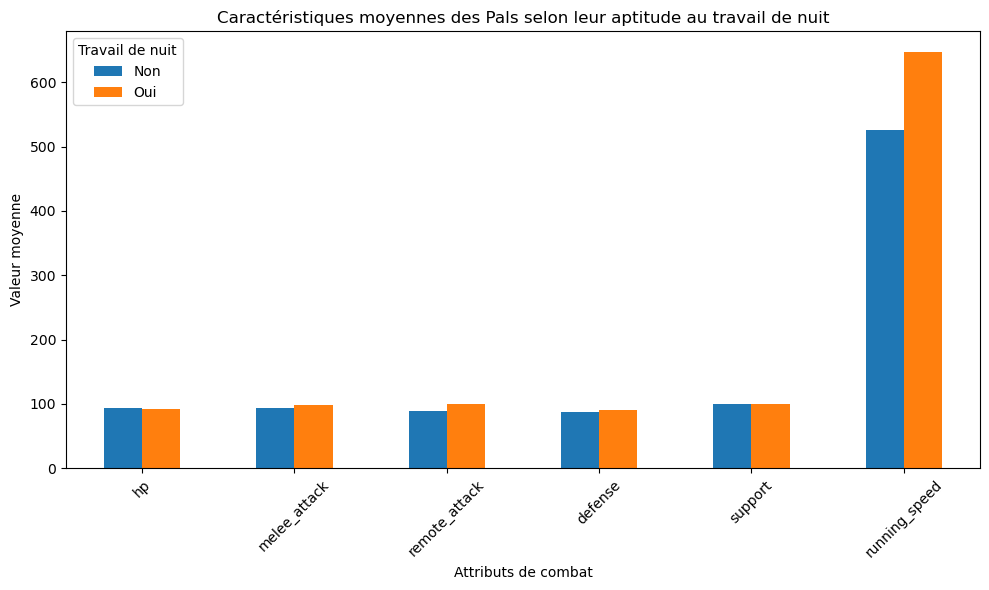

In [140]:
# q. Quelles sont les caractéristiques communes des Pals qui conviennent au travail de nuit ?

import pandas as pd
import matplotlib.pyplot as plt

# Chargement des fichiers nettoyés
job_df = pd.read_csv("clean_job_skill_ready.csv")
combat_df = pd.read_csv("clean_combat_attribute_ready.csv")

# Nettoyage de night_shift
job_df["night_shift"] = job_df["night_shift"].replace({"yes": 1}).fillna(0).astype(int)

# Fusion sur le nom anglais
merged = pd.merge(job_df, combat_df, left_on="english_name", right_on="name", how="inner")

# Moyennes des caractéristiques de combat selon night_shift
cols = ["hp", "melee_attack", "remote_attack", "defense", "support", "running_speed"]
grouped = merged.groupby("night_shift")[cols].mean()
grouped.index = grouped.index.map({0: "Non", 1: "Oui"})

# Graphique comparatif
grouped.T.plot(kind="bar", figsize=(10, 6), title="Caractéristiques moyennes des Pals selon leur aptitude au travail de nuit")
plt.ylabel("Valeur moyenne")
plt.xlabel("Attributs de combat")
plt.xticks(rotation=45)
plt.legend(title="Travail de nuit")
plt.tight_layout()
plt.show()


Question : Quelles sont les caractéristiques communes des Pals qui peuvent travailler la nuit ?

Observation :

Les Pals capables de travailler la nuit ont en moyenne :

plus de vitesse de déplacement (running_speed)

plus d’attaque à distance (remote_attack)

une attaque au corps-à-corps et une défense légèrement supérieures

Les différences de points de vie (hp) et de soutien (support) sont minimes.

Interprétation :

Ces Pals nocturnes sont rapides, mobiles, et efficaces à distance, ce qui les rend adaptés à des tâches urgentes ou à des combats rapides durant la nuit.

On peut les considérer comme des unités agiles utiles pour patrouiller, récolter rapidement ou intervenir dans des situations dynamiques.

Ils sont moins orientés tanking (pas de grande différence sur les HP), donc à éviter en première ligne.

Conclusion stratégique :

Intégrer 1 ou 2 Pals nocturnes dans son équipe permet d’assurer une activité continue au campement pendant la nuit tout en profitant de leur haute mobilité et de leur efficacité à distance.